# Accuracy Model with Fixed Kepler Data - updated 2026-04-06
re-check the accuracy model process to see if:


- One regression model captures accuracy across a range of span lengths (100ms to 1000ms was what I did before)
- The rule of thumb of four measurements per span still gives us decent accuracy (better than 20% accuracy compared to the median "ground truth"). This should aid us also having a simple overhead model since I think four measurements "costs" the same every time?


I'm expecting nothing will challenge what we found before but we'll see!

# import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

from scipy import stats
from scipy.stats import ks_2samp


sns.set_theme(style="whitegrid")

fs=24

## Import data

In [40]:
df_spans_300 = pd.read_csv("../../../Data/E2EGHG/span_300.csv")

In [41]:
df_spans_300

,trace.id,span.id,measurements.count,start_time_us,energy.joules,start.energy.joules,end.energy.joules,kepler.duration.ms,kepler.energy.joules,exper_name,cpu_ms,active_interval_ms,concurrency
0,1ea5821d6a8fa0ad3a4d62264de8ed5c,aaf34123177dd6a3,2,1775540696166682,7.377548,1178.432309,1179.653244,70,0,uniform-a,100,100,1.0
1,f03a4100613fa59a6f6e1dc8e2bb32c8,00f11b8c51d7729e,2,1775540677340915,7.311865,1039.834229,1040.469107,83,0,uniform-a,100,100,1.0
2,3e8e7c240b1f39549d89e55c2a2a32ce,20aa996537c2980a,2,1775540795264114,7.288992,110.473547,111.392257,100,0,uniform-a,100,100,1.0
3,866b5c2e6de51cf877ca48ed6b4e8caa,82b59d8a5efb3edd,2,1775540717968697,7.236388,1340.756535,1341.585087,99,0,uniform-a,100,100,1.0
4,872b66e51f39bd154ad1542fe80553fd,45b01753397306ba,2,1775540721937734,7.374696,1370.105189,1370.945295,97,0,uniform-a,100,100,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13487,84f0c207bc7cf850409bb7ba13caaf2b,063a4de1f4f6dd70,6,1775546325430563,5.359041,0.239662,5.594838,208,0,uniform-a,500,62,1.0
13488,728960a9d753b9a046900d9d74437b23,8cdf3e2fd703ba5c,6,1775546315512034,9.155061,10.834292,16.610591,188,0,uniform-a,500,62,1.0
13489,9e11773b40646f7debf5fc37e9282bc5,c066e79eba8a0ef5,6,1775546346252291,8.998294,35.821468,40.952971,234,0,uniform-a,500,62,1.0
13490,5543782e336402b00139b052ec0f0fa9,e30940845bda8a1f,5,1775546306590191,8.446099,63.661406,68.515457,249,0,uniform-a,500,62,1.0


In [42]:
df_spans_300.columns

Index(['trace.id', 'span.id', 'measurements.count', 'start_time_us',
       'energy.joules', 'start.energy.joules', 'end.energy.joules',
       'kepler.duration.ms', 'kepler.energy.joules', 'exper_name', 'cpu_ms',
       'active_interval_ms', 'concurrency'],
      dtype='str')

In [43]:
# replace . with _ in column names
df_spans_300.columns = df_spans_300.columns.str.replace('.', '_')
df_spans_300.columns

Index(['trace_id', 'span_id', 'measurements_count', 'start_time_us',
       'energy_joules', 'start_energy_joules', 'end_energy_joules',
       'kepler_duration_ms', 'kepler_energy_joules', 'exper_name', 'cpu_ms',
       'active_interval_ms', 'concurrency'],
      dtype='str')

In [45]:
# create reduced dataset for modeling
df = df_spans_300.drop([ 'trace_id', 'measurements_count', 'start_time_us','start_energy_joules', 'end_energy_joules',
       'kepler_duration_ms', 'kepler_energy_joules', 'exper_name'], axis=1)
df.head(30)

,span_id,energy_joules,cpu_ms,active_interval_ms,concurrency
0,aaf34123177dd6a3,7.377548,100,100,1.0
1,00f11b8c51d7729e,7.311865,100,100,1.0
2,20aa996537c2980a,7.288992,100,100,1.0
3,82b59d8a5efb3edd,7.236388,100,100,1.0
4,45b01753397306ba,7.374696,100,100,1.0
5,6223bb652c62a625,7.521213,100,100,1.0
6,ceb06bf901cbb9ee,7.547672,100,100,1.0
7,b811c9da69d1c4b7,0.872246,100,100,1.0
8,2460bd897030e981,7.342919,100,100,1.0
9,e6a076220d2b1e63,7.289949,100,100,1.0


#### filter out rows with too short active_interval_ms (< 25.0 ms are removed)

In [51]:
# df = df.query('active_interval_ms >= 25.0')
# df

### Get Median E for each cpu_ms

In [46]:
df_median_e_cpu = df[['energy_joules','cpu_ms']].copy()
df_median_e_cpu = df_median_e_cpu.groupby(['cpu_ms'], as_index=False).median()
df_median_e_cpu

,cpu_ms,energy_joules
0,50,6.998781
1,100,7.329111
2,150,7.480252
3,200,7.684589
4,250,7.883131
5,500,9.143268
6,1000,10.582384
7,1500,15.781766
8,2000,20.829015


### add column with median energy for that cpu_ms to each trace_id

In [62]:
cpu_ms_vals = np.unique(df['cpu_ms'])
for i in cpu_ms_vals:
    df.loc[df['cpu_ms'] == i, 'median_energy_cpu_ms'] = df_median_e_cpu[df_median_e_cpu['cpu_ms'] == i].energy_joules.values[0]

df.head(30)

,span_id,energy_joules,cpu_ms,active_interval_ms,concurrency,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs
0,aaf34123177dd6a3,7.377548,100,100,1.0,7.329111,-0.048437,-0.660885,1.0,0.660885
1,00f11b8c51d7729e,7.311865,100,100,1.0,7.329111,0.017246,0.235308,1.0,0.235308
2,20aa996537c2980a,7.288992,100,100,1.0,7.329111,0.040119,0.547392,1.0,0.547392
3,82b59d8a5efb3edd,7.236388,100,100,1.0,7.329111,0.092723,1.265133,1.0,1.265133
4,45b01753397306ba,7.374696,100,100,1.0,7.329111,-0.045585,-0.621972,1.0,0.621972
5,6223bb652c62a625,7.521213,100,100,1.0,7.329111,-0.192102,-2.621082,1.0,2.621082
6,ceb06bf901cbb9ee,7.547672,100,100,1.0,7.329111,-0.218561,-2.982094,1.0,2.982094
7,b811c9da69d1c4b7,0.872246,100,100,1.0,7.329111,6.456865,88.098884,1.0,88.098884
8,2460bd897030e981,7.342919,100,100,1.0,7.329111,-0.013808,-0.188399,1.0,0.188399
9,e6a076220d2b1e63,7.289949,100,100,1.0,7.329111,0.039162,0.534335,1.0,0.534335


Text(0, 0.5, 'Energy')

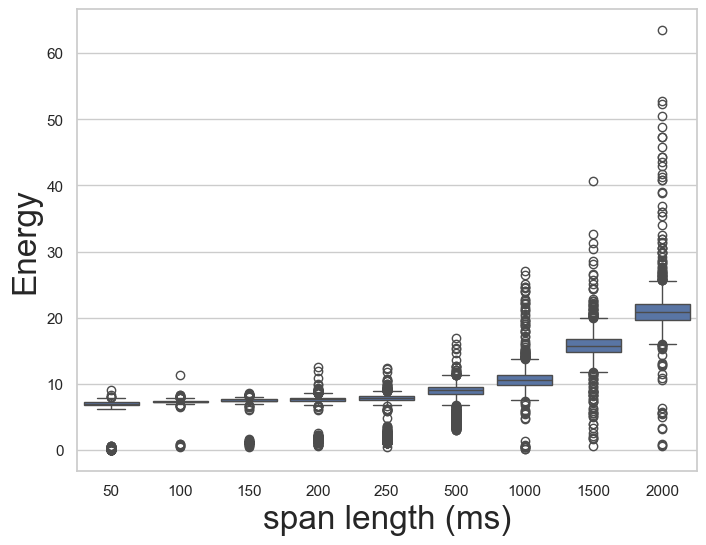

In [48]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='cpu_ms', y='energy_joules')#, col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel("span length (ms)", fontsize=fs)
plt.ylabel(r'Energy', fontsize=fs)

### From the "Taming Performance Variability" paper: "compute $\lfloor{\frac{n - z \sqrt{n}}{ 2}}\rfloor$ and $\lceil{1+\frac{n+z \sqrt{n}  }{2} }\rceil$,where n is the number of elements in X, and z is the standard score (or z-score). z depends only on the desired confidence level, and is 1.96 for the commonly-used level of $\alpha = 95\\\%$. These two numbers are then used as indexes into the sorted X: the values at those locations are the top and the bottom bounds of the CI. Note that one of these numbers will be larger than the median (at index n/2) and the other will be smaller, and they will not necessarily be symmetric around the median. These bounds tend to get tighter—to approach the sample mean—with more repetitions. Typically, we are concerned with the relative difference r% between the CI bounds and the mean."

In [7]:
# df['gender'] = df['gender'].apply(lambda x: 0 if x == 'female' else x)

#df_filtered_1000_fixed['sampling_ratio'] = df_filtered_1000_fixed['sampling_ratio'].apply(lambda x: 4.000000 if ((x > 4) & (x < 5)) else x)


#### Build confidence intervals on median Energy - note we are using all data for a span (all measurement frequencies)

In [49]:
# copy data for experimenting
df_test = df.copy()

In [50]:
span_lengths = np.unique(df_test.cpu_ms)
span_lengths

array([  50,  100,  150,  200,  250,  500, 1000, 1500, 2000])

In [51]:
# set params for conf intervals calculation
# here using the Z-score for 95% confidence

z = 1.96


temp_df = pd.DataFrame(columns=['n','cpu_ms','median_energy','e_upper_ci','e_lower_ci'])

for span_ms in span_lengths:
    the_n = df_test.query('(cpu_ms == @span_ms)').shape[0]
    lower_ci_idx = int(np.floor((the_n - z*np.sqrt(the_n))/2))
    upper_ci_idx = int(np.ceil(1 + ((the_n + z*np.sqrt(the_n))/2)))
    acc_eng = df_test.query('(cpu_ms == @span_ms)')['energy_joules']
    acc_eng_sorted = np.sort(acc_eng)
    acc_eng_upper_ci = acc_eng_sorted[upper_ci_idx]
    acc_eng_lower_ci = acc_eng_sorted[lower_ci_idx]
    temp_df.loc[len(temp_df.index)] = [the_n, span_ms, acc_eng.median(), acc_eng_upper_ci, acc_eng_lower_ci]
        #print(the_n,span_ms,ratio,acc_eng_upper_ci,acc_eng_lower_ci)

temp_df
        

,n,cpu_ms,median_energy,e_upper_ci,e_lower_ci
0,600.0,50.0,6.998781,7.032368,6.965973
1,900.0,100.0,7.329111,7.343786,7.315729
2,900.0,150.0,7.480252,7.500269,7.462912
3,1200.0,200.0,7.684589,7.703698,7.662573
4,1500.0,250.0,7.883131,7.911234,7.863231
5,1800.0,500.0,9.143268,9.187684,9.099913
6,2099.0,1000.0,10.582384,10.644312,10.515633
7,2097.0,1500.0,15.781766,15.865100,15.673567
8,2396.0,2000.0,20.829015,20.907465,20.731983


In [52]:
# save those energies and CIs for later
df_median_energy_with_ci = temp_df.copy()
df_median_energy_with_ci

,n,cpu_ms,median_energy,e_upper_ci,e_lower_ci
0,600.0,50.0,6.998781,7.032368,6.965973
1,900.0,100.0,7.329111,7.343786,7.315729
2,900.0,150.0,7.480252,7.500269,7.462912
3,1200.0,200.0,7.684589,7.703698,7.662573
4,1500.0,250.0,7.883131,7.911234,7.863231
5,1800.0,500.0,9.143268,9.187684,9.099913
6,2099.0,1000.0,10.582384,10.644312,10.515633
7,2097.0,1500.0,15.781766,15.865100,15.673567
8,2396.0,2000.0,20.829015,20.907465,20.731983


## Plot Median E with CIs

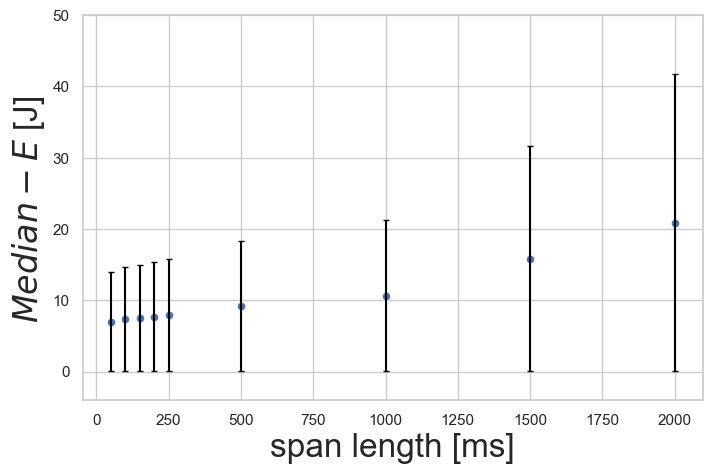

In [56]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=temp_df, x='cpu_ms', y='median_energy')
plt.errorbar(temp_df['cpu_ms'], temp_df['median_energy'], yerr=[temp_df['e_lower_ci'],temp_df['e_upper_ci'] ], fmt='none', capsize=2,color='black')
# plt.plot(x_vals, reg_model(x_vals), color="black", linestyle="--")
plt.ylim(-4,50)
plt.xlabel("span length [ms]", fontsize=fs)
plt.ylabel(r'$Median-E$ [J] ', fontsize=fs)
#plt.title("cpu_ms = "+str(i)+" OLS model vs data")
plt.show()

## Back to Accuracy Modeling

In [95]:
df

,span_id,energy_joules,cpu_ms,active_interval_ms,concurrency,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs
0,aaf34123177dd6a3,7.377548,100,100,1.0,7.329111,-0.048437,-0.660885,1.000000,0.660885
1,00f11b8c51d7729e,7.311865,100,100,1.0,7.329111,0.017246,0.235308,1.000000,0.235308
2,20aa996537c2980a,7.288992,100,100,1.0,7.329111,0.040119,0.547392,1.000000,0.547392
3,82b59d8a5efb3edd,7.236388,100,100,1.0,7.329111,0.092723,1.265133,1.000000,1.265133
4,45b01753397306ba,7.374696,100,100,1.0,7.329111,-0.045585,-0.621972,1.000000,0.621972
...,...,...,...,...,...,...,...,...,...,...
13487,063a4de1f4f6dd70,5.359041,500,62,1.0,9.143268,3.784227,41.388120,8.064516,41.388120
13488,8cdf3e2fd703ba5c,9.155061,500,62,1.0,9.143268,-0.011793,-0.128986,8.064516,0.128986
13489,c066e79eba8a0ef5,8.998294,500,62,1.0,9.143268,0.144974,1.585576,8.064516,1.585576
13490,e30940845bda8a1f,8.446099,500,62,1.0,9.143268,0.697169,7.624938,8.064516,7.624938


### calculate deviation per trace E from median for that cpu_ms

In [96]:
df['energy_devation'] = (df.median_energy_cpu_ms - df.energy_joules) 
df

,span_id,energy_joules,cpu_ms,active_interval_ms,concurrency,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs
0,aaf34123177dd6a3,7.377548,100,100,1.0,7.329111,-0.048437,-0.660885,1.000000,0.660885
1,00f11b8c51d7729e,7.311865,100,100,1.0,7.329111,0.017246,0.235308,1.000000,0.235308
2,20aa996537c2980a,7.288992,100,100,1.0,7.329111,0.040119,0.547392,1.000000,0.547392
3,82b59d8a5efb3edd,7.236388,100,100,1.0,7.329111,0.092723,1.265133,1.000000,1.265133
4,45b01753397306ba,7.374696,100,100,1.0,7.329111,-0.045585,-0.621972,1.000000,0.621972
...,...,...,...,...,...,...,...,...,...,...
13487,063a4de1f4f6dd70,5.359041,500,62,1.0,9.143268,3.784227,41.388120,8.064516,41.388120
13488,8cdf3e2fd703ba5c,9.155061,500,62,1.0,9.143268,-0.011793,-0.128986,8.064516,0.128986
13489,c066e79eba8a0ef5,8.998294,500,62,1.0,9.143268,0.144974,1.585576,8.064516,1.585576
13490,e30940845bda8a1f,8.446099,500,62,1.0,9.143268,0.697169,7.624938,8.064516,7.624938


### and add columns for % deviation from median for that cpu_ms, sampling ratio, and accuracy
#### an accuracy of 1.0 would mean it got the span mean energy value exactly for that trace

In [97]:
df['energy_deviation_pct'] = 100 * df.energy_devation / df.median_energy_cpu_ms
df['sampling_ratio'] = df.cpu_ms / df.active_interval_ms
df['energy_deviation_pct_abs'] = np.abs(df.energy_deviation_pct)

In [67]:
df


,span_id,energy_joules,cpu_ms,active_interval_ms,concurrency,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs
0,aaf34123177dd6a3,7.377548,100,100,1.0,7.329111,-0.048437,-0.660885,1.000000,0.660885
1,00f11b8c51d7729e,7.311865,100,100,1.0,7.329111,0.017246,0.235308,1.000000,0.235308
2,20aa996537c2980a,7.288992,100,100,1.0,7.329111,0.040119,0.547392,1.000000,0.547392
3,82b59d8a5efb3edd,7.236388,100,100,1.0,7.329111,0.092723,1.265133,1.000000,1.265133
4,45b01753397306ba,7.374696,100,100,1.0,7.329111,-0.045585,-0.621972,1.000000,0.621972
...,...,...,...,...,...,...,...,...,...,...
13487,063a4de1f4f6dd70,5.359041,500,62,1.0,9.143268,3.784227,41.388120,8.064516,41.388120
13488,8cdf3e2fd703ba5c,9.155061,500,62,1.0,9.143268,-0.011793,-0.128986,8.064516,0.128986
13489,c066e79eba8a0ef5,8.998294,500,62,1.0,9.143268,0.144974,1.585576,8.064516,1.585576
13490,e30940845bda8a1f,8.446099,500,62,1.0,9.143268,0.697169,7.624938,8.064516,7.624938


In [98]:
# copy data to preserve original
df_filtered = df.copy()

In [99]:
np.unique(df_filtered.sampling_ratio)

array([ 1.        ,  2.        ,  4.        ,  4.03225806,  4.05405405,
        8.        ,  8.02139037,  8.06451613, 10.        , 12.        ,
       20.        , 24.19354839, 40.        , 60.        , 80.        ])

#### In this data there are some with a sampling ratio very close to but not exactly 4 and 8. Going to merge those with values close to 4 with those with exactly 4, same for 8

In [100]:

df_filtered.query('(sampling_ratio > 4) & (sampling_ratio < 5)').sampling_ratio

3299     4.054054
3300     4.054054
3301     4.054054
3302     4.054054
3303     4.054054
           ...   
11087    4.032258
11088    4.032258
11089    4.032258
11090    4.032258
11091    4.032258
Name: sampling_ratio, Length: 600, dtype: float64

In [101]:
# df['gender'] = df['gender'].apply(lambda x: 0 if x == 'female' else x)

df_filtered['sampling_ratio'] = df_filtered['sampling_ratio'].apply(lambda x: 4.000000 if ((x > 4) & (x < 5)) else x)
df_filtered['sampling_ratio'] = df_filtered['sampling_ratio'].apply(lambda x: 8.000000 if ((x > 8) & (x < 9)) else x)

# update recip ratio
df_filtered['recip_sampling_ratio'] = 1 / df_filtered.sampling_ratio
df_filtered['sqrt_recip_sampling_ratio'] = np.sqrt(df_filtered['recip_sampling_ratio'])

print(np.unique(df_filtered['recip_sampling_ratio']))
# check it
# df_filtered_1000_fixed.query('(sampling_ratio == 4) & (sampling_ratio < 5)').sampling_ratio.count()
# df_filtered_1000_fixed.groupby('sampling_ratio').size(), df_filtered_1000_fixed.groupby('recip_sampling_ratio').size()

[0.0125     0.01666667 0.025      0.04133333 0.05       0.08333333
 0.1        0.125      0.25       0.5        1.        ]


#### Looks cleaned up - moving on to modeling

#### Rebuild dataframe of median accuracy values

In [102]:
df_median_dev = df_filtered.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).median()
df_median_dev = df_median_dev.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'median_energy_deviation'})
df_median_dev['recip_sampling_ratio'] = 1 / df_median_dev.sampling_ratio
df_median_dev['sqrt_recip_sampling_ratio'] = np.sqrt(df_median_dev['recip_sampling_ratio'])
df_median_dev

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio,sqrt_recip_sampling_ratio
0,50,1.000000,2.877965,1.000000,1.000000
1,50,2.000000,3.155128,0.500000,0.707107
2,100,1.000000,1.538509,1.000000,1.000000
3,100,2.000000,1.797599,0.500000,0.707107
4,100,4.000000,1.580424,0.250000,0.500000
5,150,1.000000,1.675846,1.000000,1.000000
6,150,2.000000,2.024083,0.500000,0.707107
7,150,4.000000,2.160636,0.250000,0.500000
8,200,1.000000,2.294156,1.000000,1.000000
9,200,2.000000,3.997143,0.500000,0.707107


#### plot accuracy vs sampling ratio and recip sampling ratio

Text(37.15625, 0.5, '$Median ({\\Delta E})$ %')

<Figure size 1000x1000 with 0 Axes>

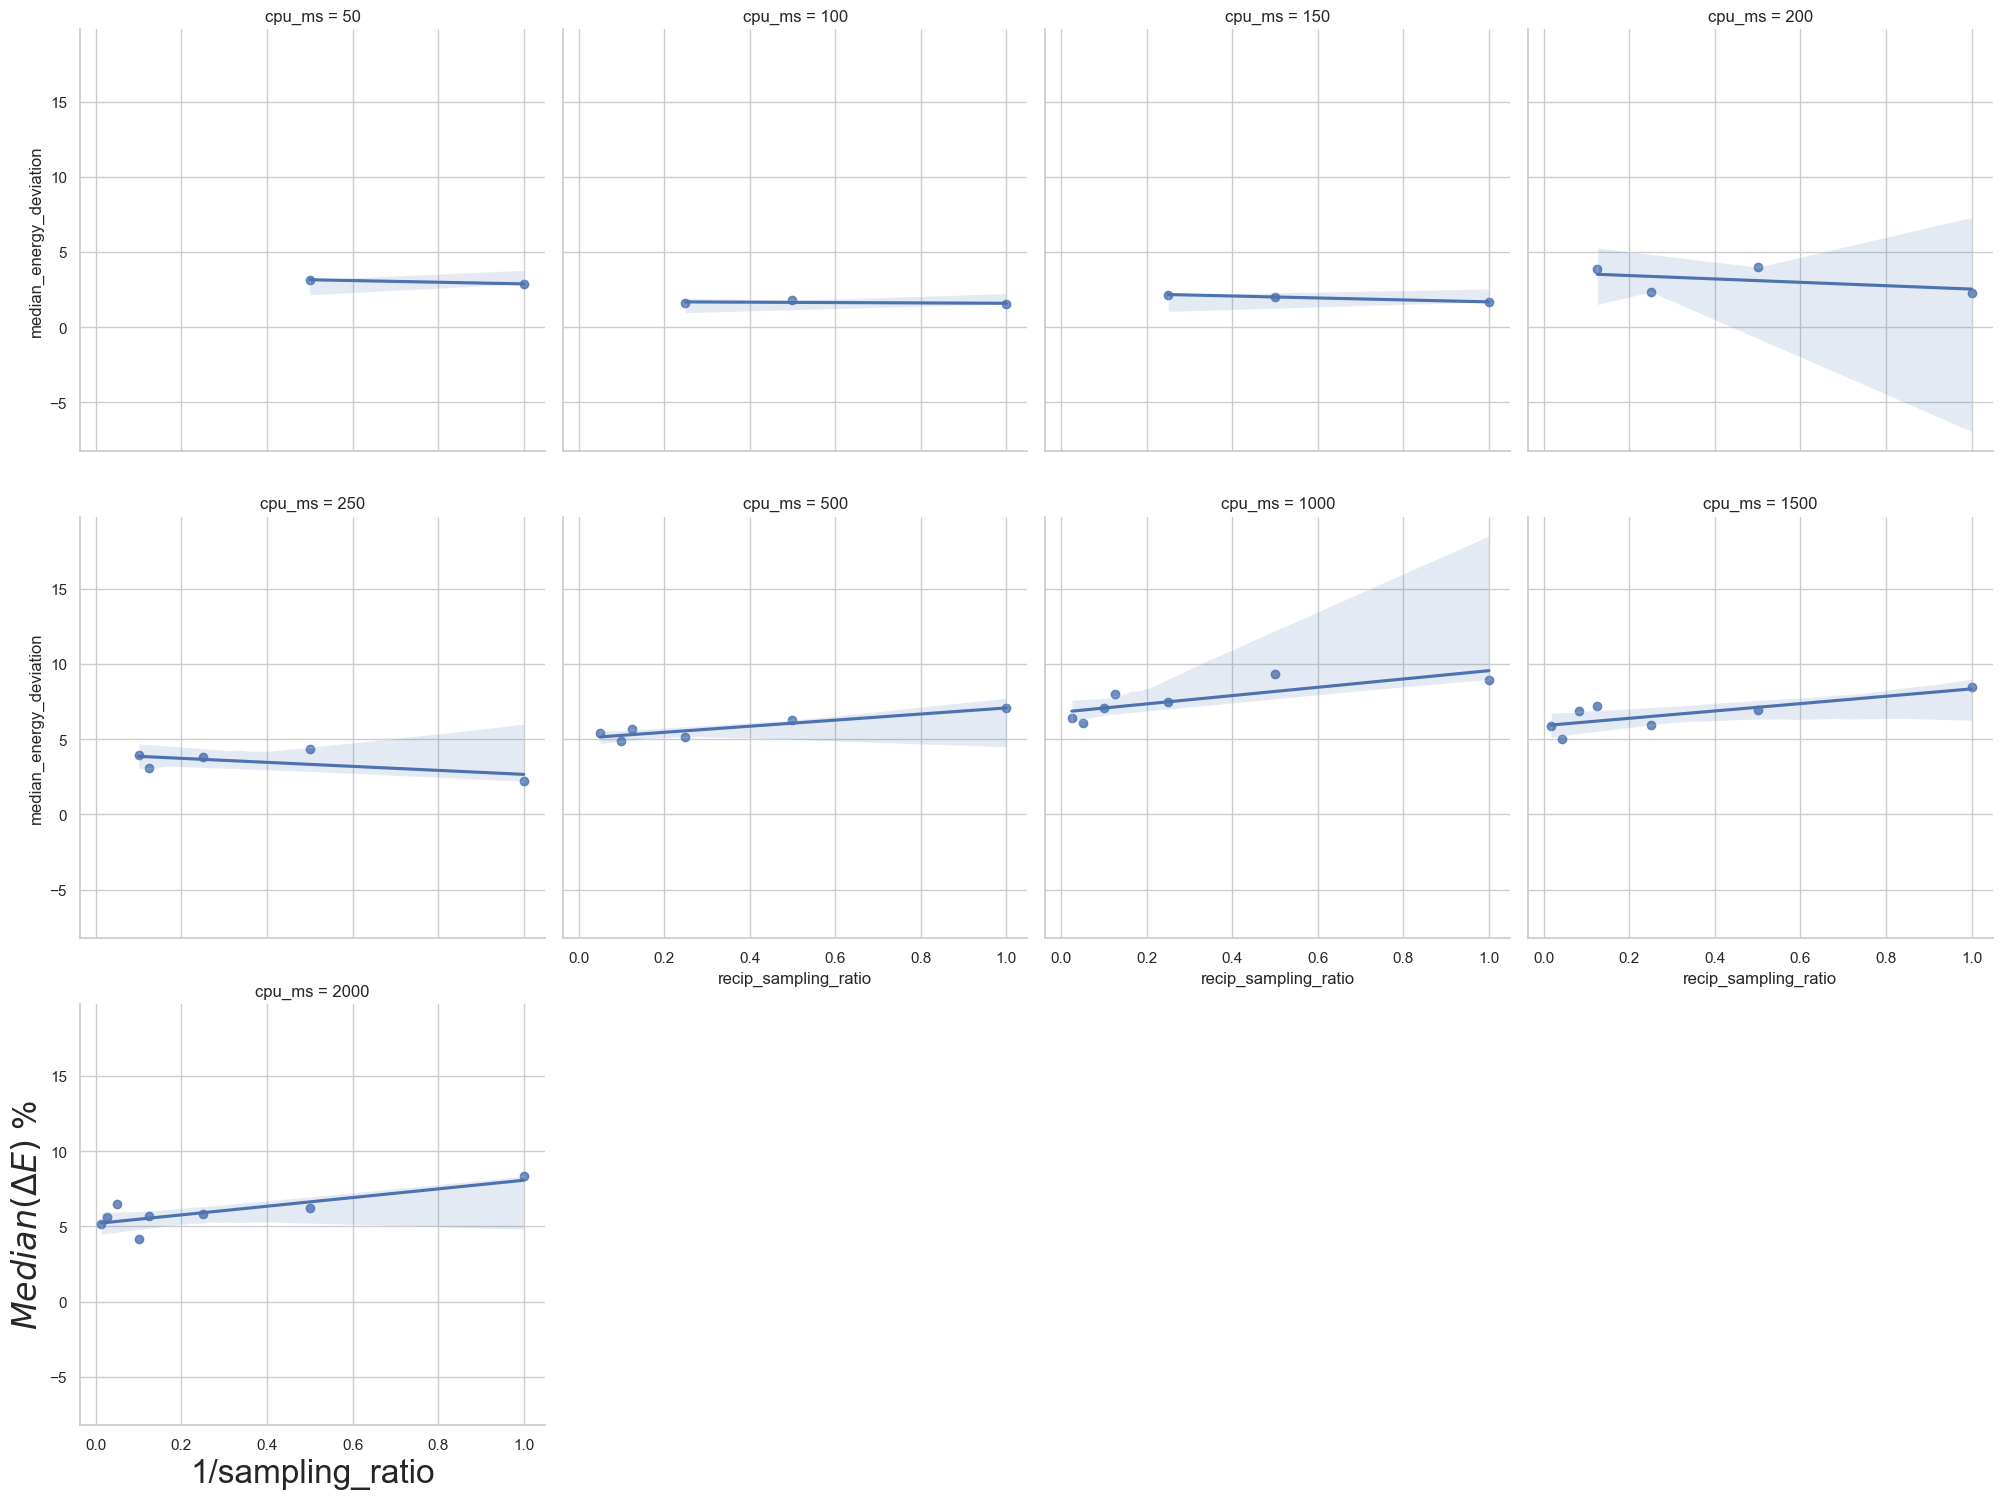

In [103]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_median_dev, x='recip_sampling_ratio', y='median_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel("1/sampling_ratio", fontsize=fs)
plt.ylabel(r'$Median ({\Delta E})$ %', fontsize=fs)

Text(28.65625, 0.5, '$Median ({\\Delta E})$ %')

<Figure size 1000x1000 with 0 Axes>

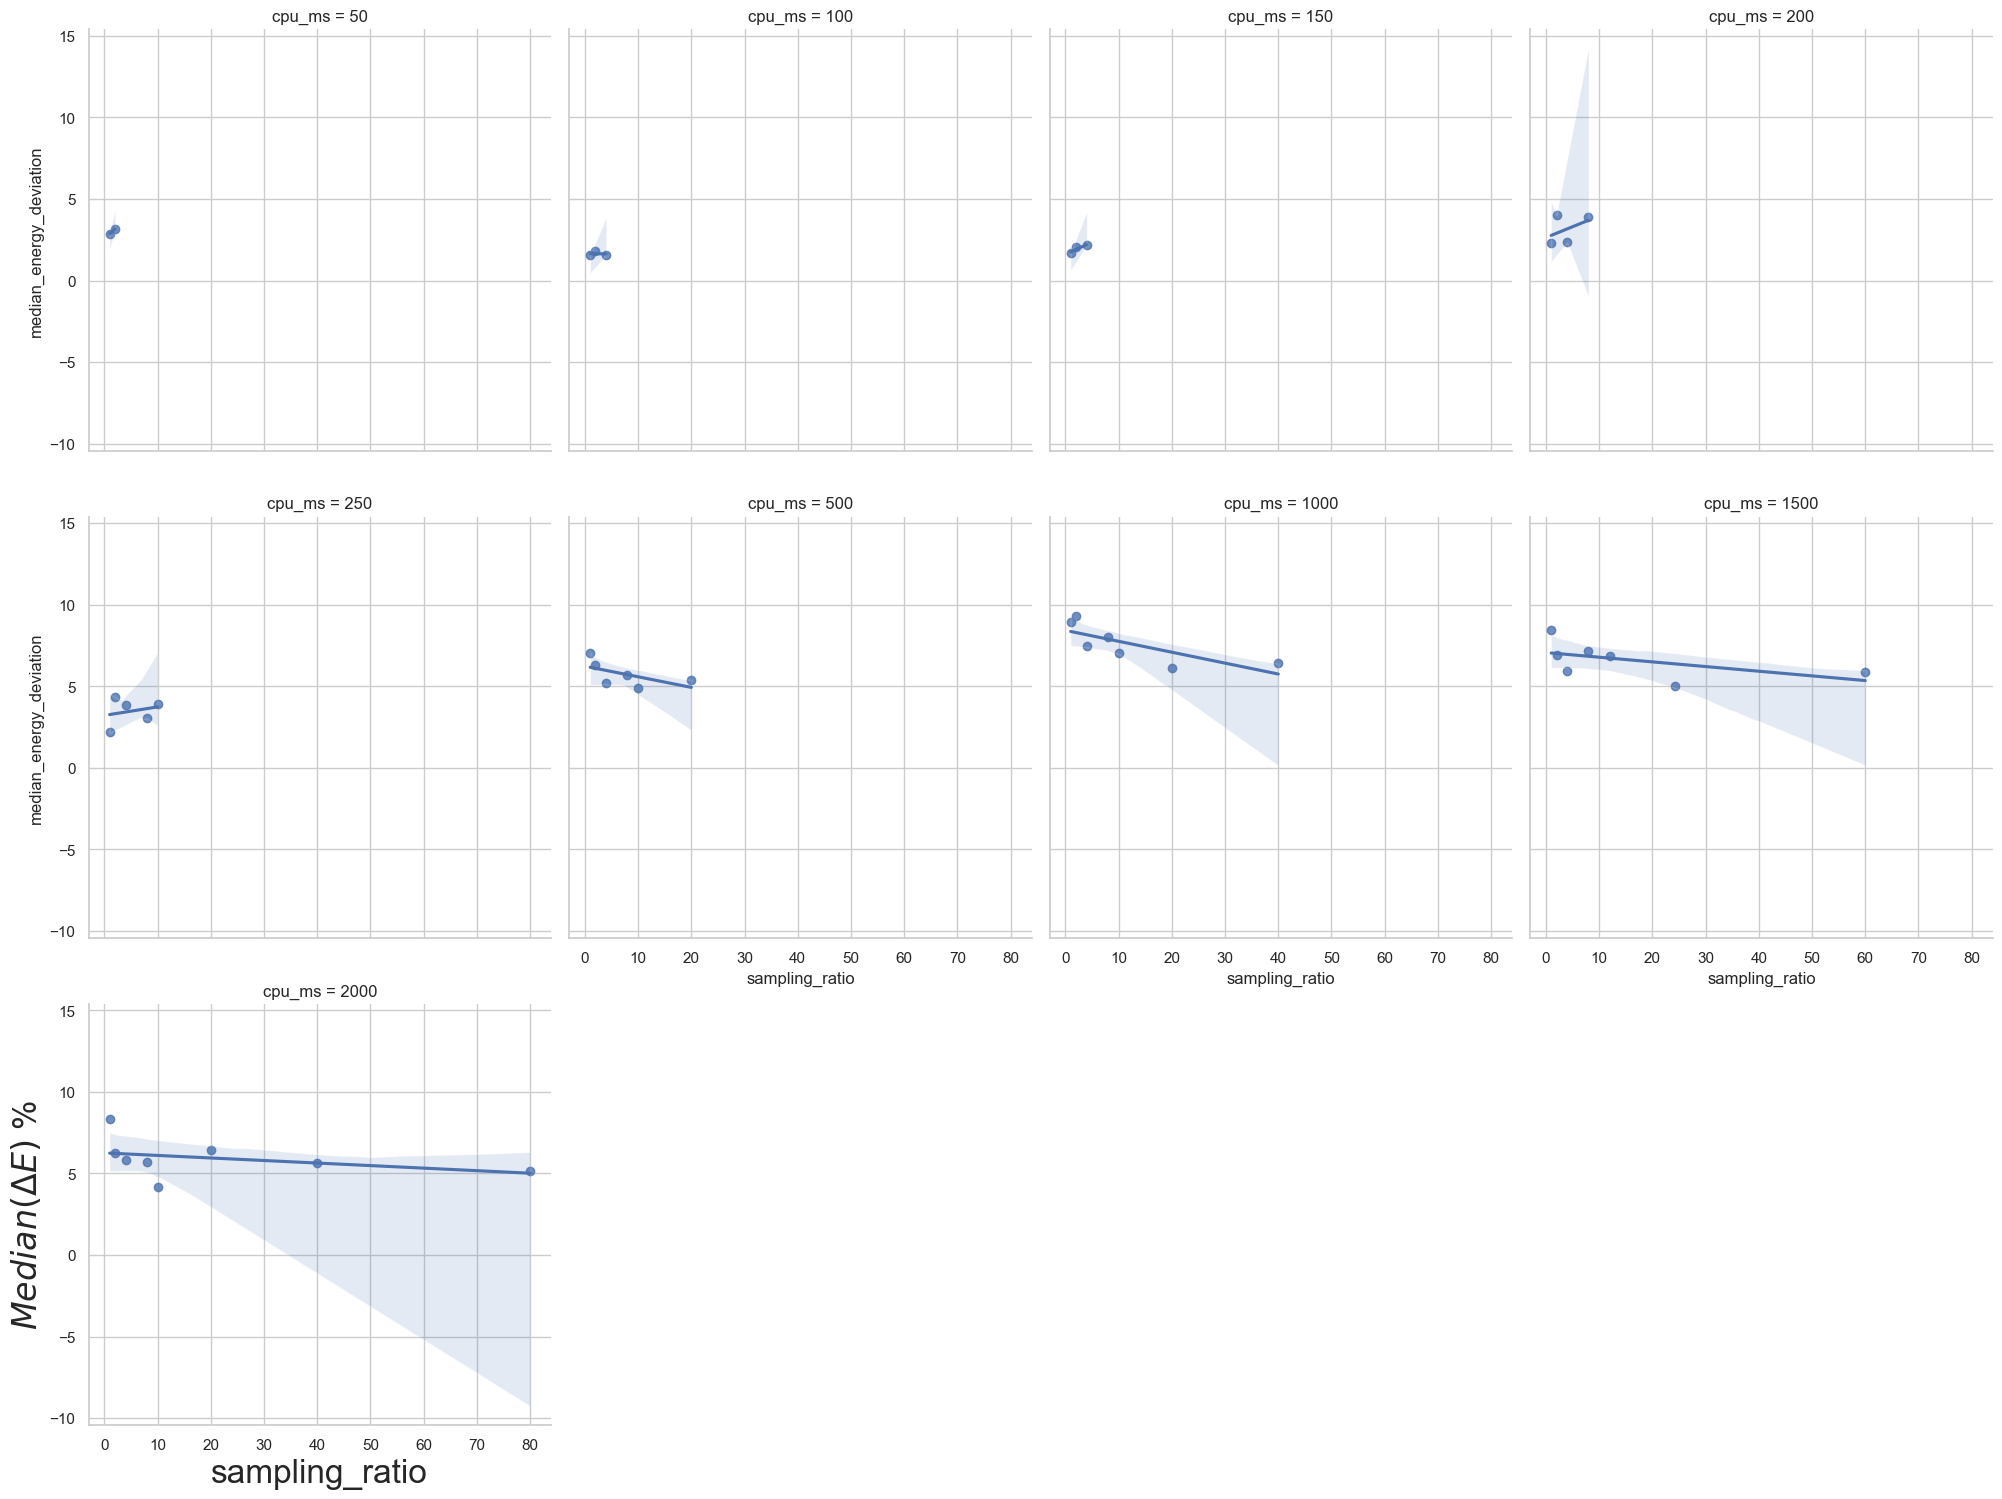

In [104]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_median_dev, x='sampling_ratio', y='median_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel("sampling_ratio", fontsize=fs)
plt.ylabel(r'$Median ({\Delta E})$ %', fontsize=fs)

#### versus sqrt recip sampling ratio?

Text(37.15625, 0.5, '$Median ({\\Delta E})$ %')

<Figure size 1000x1000 with 0 Axes>

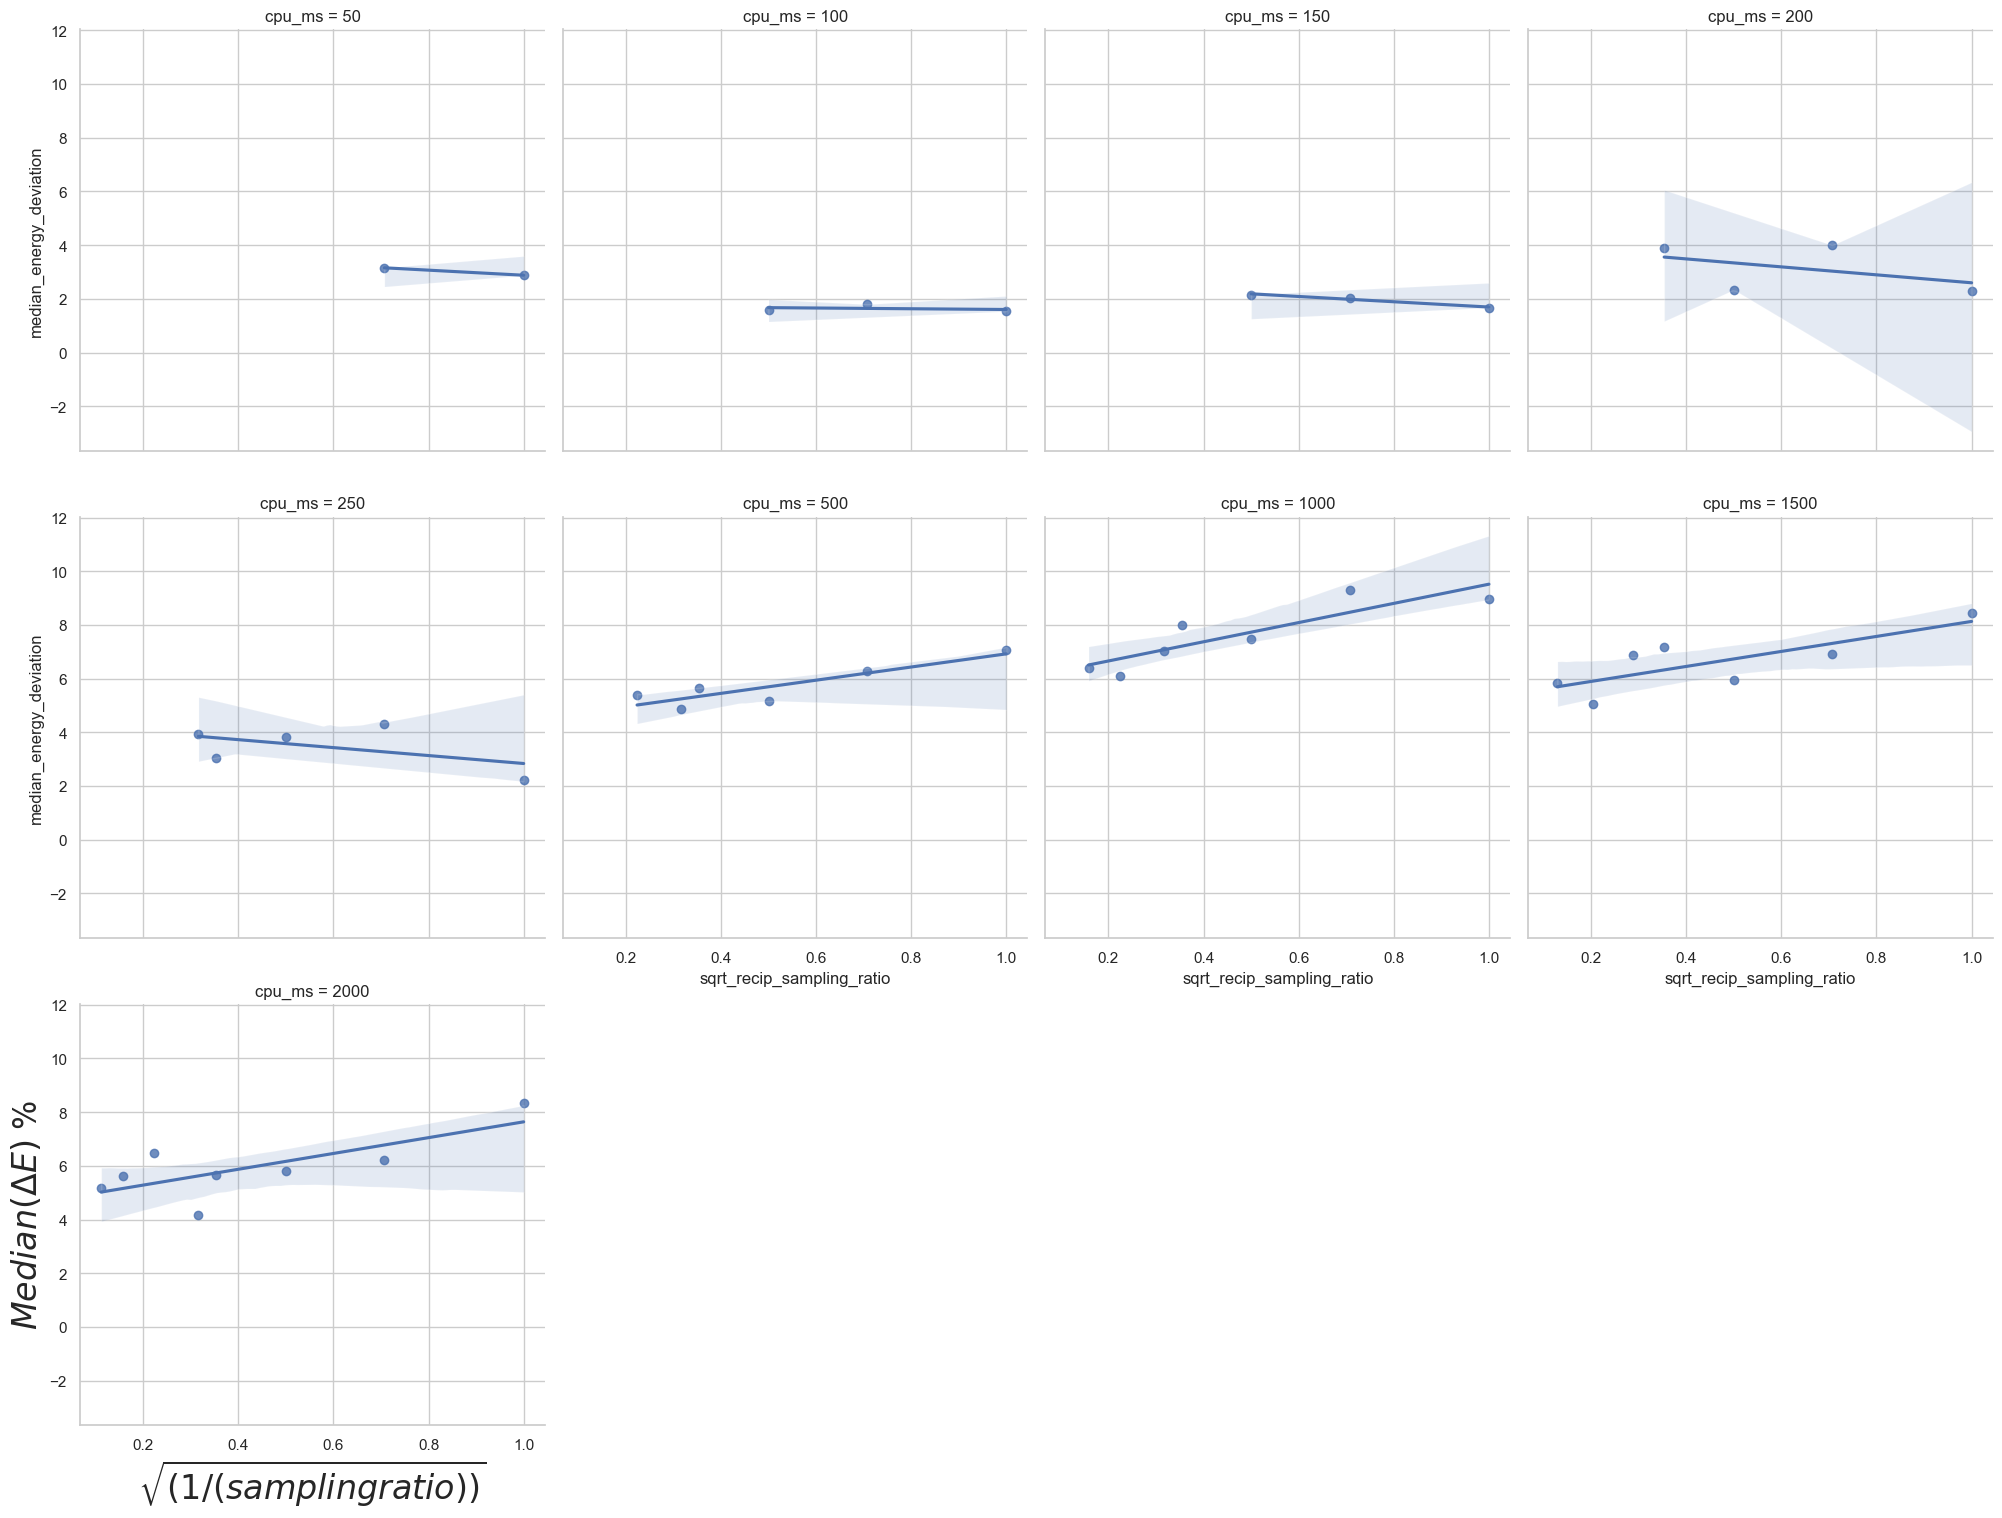

In [105]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_median_dev, x='sqrt_recip_sampling_ratio', y='median_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel(r"$\sqrt{(1/(sampling ratio))}$", fontsize=fs)
plt.ylabel(r'$Median ({\Delta E})$ %', fontsize=fs)

## Accuracy vs recip sampling ratio looks best!


#### Build confidence intervals on accuracy per span length and reciprocal sampling ratio

In [106]:
span_lengths = np.unique(df_median_dev.cpu_ms)
span_lengths

array([  50,  100,  150,  200,  250,  500, 1000, 1500, 2000])

In [108]:
# set params for conf intervals calculation
# here using the Z-score for 95% confidence

z = 1.96


temp_df = pd.DataFrame(columns=['n','cpu_ms','recip_sampling_ratio','delta_e_upper_ci','delta_e_lower_ci'])

for span_ms in span_lengths:
    print("span_ms is "+str(span_ms))
    ratio_list = np.unique(df_filtered.query('cpu_ms == @span_ms').recip_sampling_ratio)
    for ratio in ratio_list:
        print("recip ratio is "+str(ratio))
        the_n = df_filtered.query('(cpu_ms == @span_ms) & (recip_sampling_ratio == @ratio)').shape[0]
        lower_ci_idx = int(np.floor((the_n - z*np.sqrt(the_n))/2))
        upper_ci_idx = int(np.ceil(1 + ((the_n + z*np.sqrt(the_n))/2)))
        acc_eng = df_filtered.query('(cpu_ms == @span_ms) & (recip_sampling_ratio == @ratio)')['energy_deviation_pct_abs']
        acc_eng_sorted = np.sort(acc_eng)
        acc_eng_upper_ci = acc_eng_sorted[upper_ci_idx]
        acc_eng_lower_ci = acc_eng_sorted[lower_ci_idx]
        temp_df.loc[len(temp_df.index)] = [the_n, span_ms, ratio, acc_eng_upper_ci, acc_eng_lower_ci]
        #print(the_n,span_ms,ratio,acc_eng_upper_ci,acc_eng_lower_ci)

temp_df
        

span_ms is 50
recip ratio is 0.5
recip ratio is 1.0
span_ms is 100
recip ratio is 0.25
recip ratio is 0.5
recip ratio is 1.0
span_ms is 150
recip ratio is 0.25
recip ratio is 0.5
recip ratio is 1.0
span_ms is 200
recip ratio is 0.125
recip ratio is 0.25
recip ratio is 0.5
recip ratio is 1.0
span_ms is 250
recip ratio is 0.1
recip ratio is 0.125
recip ratio is 0.25
recip ratio is 0.5
recip ratio is 1.0
span_ms is 500
recip ratio is 0.05
recip ratio is 0.1
recip ratio is 0.125
recip ratio is 0.25
recip ratio is 0.5
recip ratio is 1.0
span_ms is 1000
recip ratio is 0.025
recip ratio is 0.05
recip ratio is 0.1
recip ratio is 0.125
recip ratio is 0.25
recip ratio is 0.5
recip ratio is 1.0
span_ms is 1500
recip ratio is 0.016666666666666666
recip ratio is 0.04133333333333333
recip ratio is 0.08333333333333333
recip ratio is 0.125
recip ratio is 0.25
recip ratio is 0.5
recip ratio is 1.0
span_ms is 2000
recip ratio is 0.0125
recip ratio is 0.025
recip ratio is 0.05
recip ratio is 0.1
recip ra

,n,cpu_ms,recip_sampling_ratio,delta_e_upper_ci,delta_e_lower_ci
0,300.0,50.0,0.500000,3.495452,2.814876
1,300.0,50.0,1.000000,3.435313,2.393145
2,300.0,100.0,0.250000,1.983788,1.402312
3,300.0,100.0,0.500000,2.030956,1.624112
4,300.0,100.0,1.000000,1.766463,1.399037
5,300.0,150.0,0.250000,2.334600,2.018354
6,300.0,150.0,0.500000,2.351819,1.822800
7,300.0,150.0,1.000000,1.934200,1.490765
8,300.0,200.0,0.125000,4.355021,3.314367
9,300.0,200.0,0.250000,2.803852,2.082564


### add columns with CI values for that cpu_ms and recip sampling ratio

In [110]:
cpu_ms_vals = np.unique(df_median_dev['cpu_ms'])
#ratio_vals = np.unique(df_median_dev_1000['recip_sampling_ratio'])

for i in cpu_ms_vals:
    ratio_vals = np.unique(df_median_dev.query('cpu_ms == @i').recip_sampling_ratio)    
    for j in ratio_vals:
        # copy in CI values
        df_median_dev.loc[(df_median_dev['cpu_ms'] == i) & (df_median_dev['recip_sampling_ratio'] == j), 
            'delta_e_upper_ci'] = temp_df[(temp_df['cpu_ms'] == i) & (temp_df['recip_sampling_ratio'] == j)].delta_e_upper_ci.values[0]
        df_median_dev.loc[(df_median_dev['cpu_ms'] == i) & (df_median_dev['recip_sampling_ratio'] == j), 
            'delta_e_lower_ci'] = temp_df[(temp_df['cpu_ms'] == i) & (temp_df['recip_sampling_ratio'] == j)].delta_e_lower_ci.values[0]

df_median_dev.head(10)

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio,sqrt_recip_sampling_ratio,delta_e_upper_ci,delta_e_lower_ci
0,50,1.0,2.877965,1.00,1.000000,3.435313,2.393145
1,50,2.0,3.155128,0.50,0.707107,3.495452,2.814876
2,100,1.0,1.538509,1.00,1.000000,1.766463,1.399037
3,100,2.0,1.797599,0.50,0.707107,2.030956,1.624112
4,100,4.0,1.580424,0.25,0.500000,1.983788,1.402312
5,150,1.0,1.675846,1.00,1.000000,1.934200,1.490765
6,150,2.0,2.024083,0.50,0.707107,2.351819,1.822800
7,150,4.0,2.160636,0.25,0.500000,2.334600,2.018354
8,200,1.0,2.294156,1.00,1.000000,2.643622,1.863437
9,200,2.0,3.997143,0.50,0.707107,4.599302,3.380239


#### now can use those CIs in plot of model performance

### generate linear model w/ recip sampling ratio

In [115]:
df_median_dev.columns

Index(['cpu_ms', 'sampling_ratio', 'median_energy_deviation',
       'recip_sampling_ratio', 'sqrt_recip_sampling_ratio', 'delta_e_upper_ci',
       'delta_e_lower_ci'],
      dtype='str')

#### All span lengths to 2000 ms

In [116]:
# # define x & y
# df_sub1000 = df_median_dev_1000.query("cpu_ms <= 1000.0")
X = df_median_dev.drop(['cpu_ms','sampling_ratio', 'median_energy_deviation',
       'sqrt_recip_sampling_ratio','delta_e_upper_ci',
       'delta_e_lower_ci'], axis=1)
y = df_median_dev['median_energy_deviation']


#### do a train/test split of 80/20 so I can determine RMSE and $R^{2}$ on out-of-sample data

In [117]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 47)

#### build model and check coefficients

In [118]:
mlr = LinearRegression()  
mlr.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(X, mlr.coef_)), "\n Intercept: ", mlr.intercept_)

Coefficients:  [('recip_sampling_ratio', np.float64(-1.2995143911169347))] 
 Intercept:  5.438948886414503


In [119]:
# make predictions based on test data
y_pred = mlr.predict(x_test)

In [120]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  2.023469616042318
The R^2 is:  -0.4444275323946614


#### Low RMSE relative to Energy and $R^{2} = -0.44$ is surprising - check plots

#### Plot some of the fits and original data

#### make function for using regression model in plot

In [121]:
# make function for using regression model
def reg_model(recip_sampling_ratio):
    return (mlr.intercept_ + mlr.coef_[0]*recip_sampling_ratio)

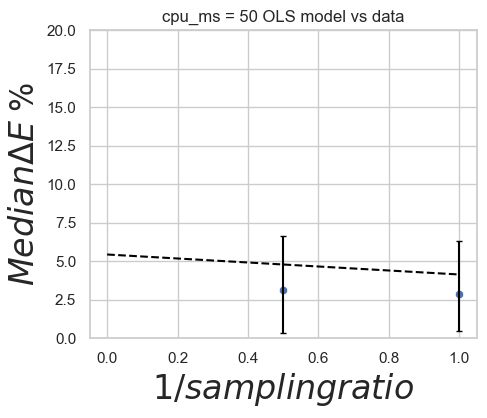

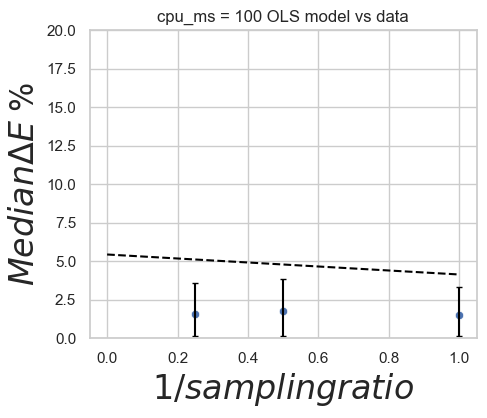

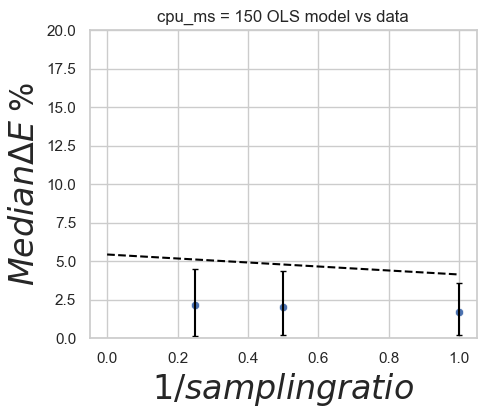

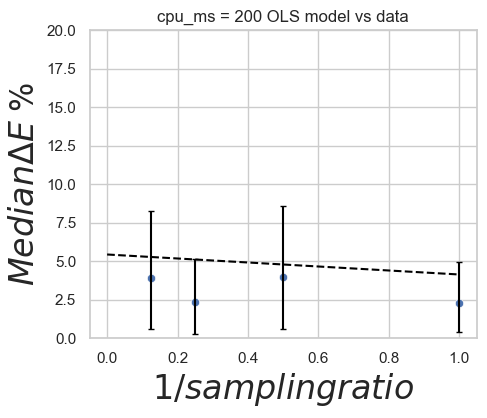

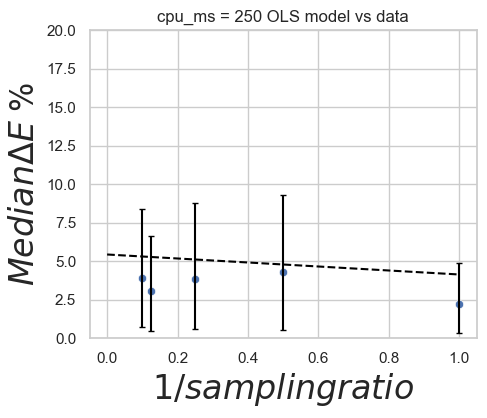

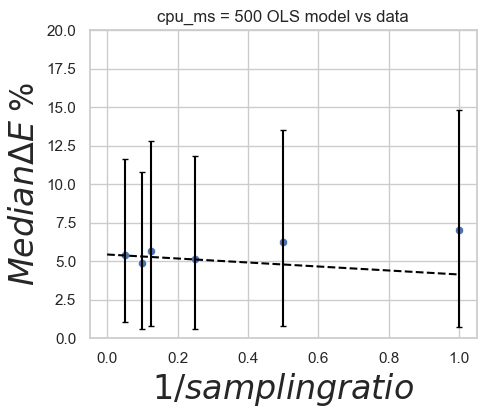

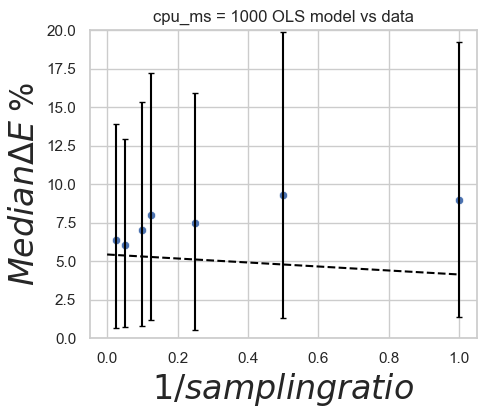

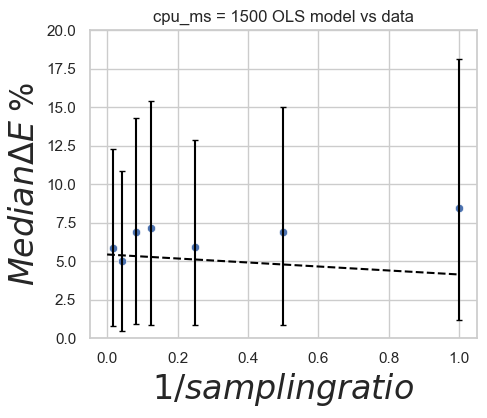

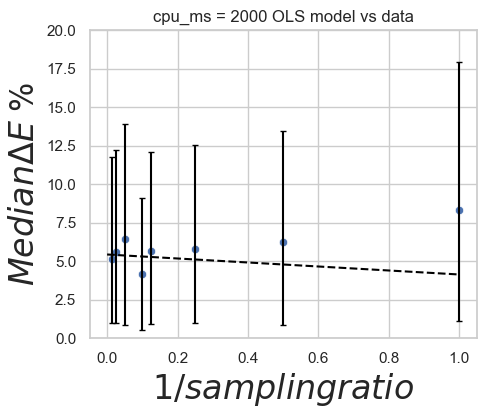

In [122]:
span_lengths = np.unique(df_median_dev.cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    tmp_df = df_median_dev.drop(['sampling_ratio','sqrt_recip_sampling_ratio'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(5,4))
    sns.scatterplot(data=tmp_df, x=tmp_df['recip_sampling_ratio'], y=tmp_df['median_energy_deviation'])
    plt.errorbar(tmp_df['recip_sampling_ratio'], tmp_df['median_energy_deviation'], yerr=[tmp_df['delta_e_lower_ci'],tmp_df['delta_e_upper_ci'] ], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, reg_model(x_vals), color="black", linestyle="--")
    plt.ylim(0,20)
    plt.xlabel(r"${1/samplingratio}$", fontsize=fs)
    plt.ylabel(r'$Median \Delta E$ %', fontsize=fs)
    plt.title("cpu_ms = "+str(i)+" OLS model vs data")
    plt.show()

In [88]:
print("Coefficients: ", list(zip(X, mlr.coef_)), "\n Intercept: ", mlr.intercept_)

Coefficients:  [('sqrt_recip_sampling_ratio', np.float64(-1.8077829604959705))] 
 Intercept:  5.930504231627383


## Accuracy looks pretty constant for spans < 500 ms
- build model for spans 500 and longer only

#### All span lengths 500 ms to 2000 ms

In [132]:
df_model = df_median_dev.query("cpu_ms >= 500")
df_model

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio,sqrt_recip_sampling_ratio,delta_e_upper_ci,delta_e_lower_ci
17,500,1.000000,7.058598,1.000000,1.000000,7.754553,6.346982
18,500,2.000000,6.274354,0.500000,0.707107,7.229609,5.487026
19,500,4.000000,5.164631,0.250000,0.500000,6.668792,4.572802
20,500,8.000000,5.668203,0.125000,0.353553,7.151016,4.887481
21,500,10.000000,4.870606,0.100000,0.316228,5.929013,4.248552
22,500,20.000000,5.389556,0.050000,0.223607,6.269668,4.314021
23,1000,1.000000,8.949349,1.000000,1.000000,10.271136,7.577867
24,1000,2.000000,9.314220,0.500000,0.707107,10.589608,8.003735
25,1000,4.000000,7.468114,0.250000,0.500000,8.475122,6.918016
26,1000,8.000000,7.989107,0.125000,0.353553,9.263026,6.808778


In [133]:
# # define x & y
# df_sub1000 = df_median_dev_1000.query("cpu_ms <= 1000.0")
X = df_model.drop(['cpu_ms','sampling_ratio', 'median_energy_deviation',
       'sqrt_recip_sampling_ratio','delta_e_upper_ci',
       'delta_e_lower_ci'], axis=1)
y = df_model['median_energy_deviation']


#### do a train/test split of 80/20 so I can determine RMSE and $R^{2}$ on out-of-sample data

In [134]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 47)

#### build model and check coefficients

In [135]:
mlr = LinearRegression()  
mlr.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(X, mlr.coef_)), "\n Intercept: ", mlr.intercept_)

Coefficients:  [('recip_sampling_ratio', np.float64(2.7130457841310434))] 
 Intercept:  5.595156880868971


In [136]:
# make predictions based on test data
y_pred = mlr.predict(x_test)

In [137]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  0.7204810324661228
The R^2 is:  -0.5154071101019098


#### Low RMSE relative to Energy and $R^{2} = -0.52$ means a horizontal line is just as good

#### Plot some of the fits and original data

#### make function for using regression model in plot

In [129]:
# make function for using regression model
def reg_model(recip_sampling_ratio):
    return (mlr.intercept_ + mlr.coef_[0]*recip_sampling_ratio)

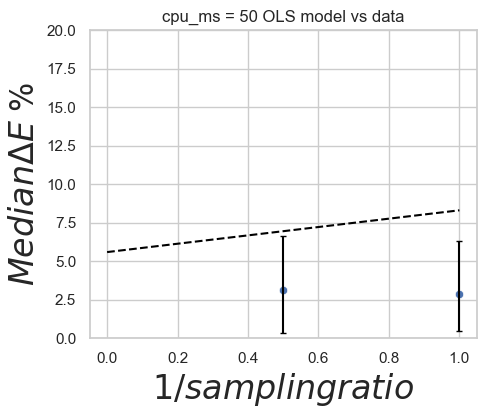

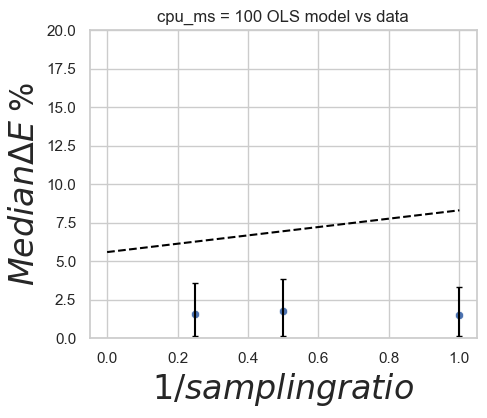

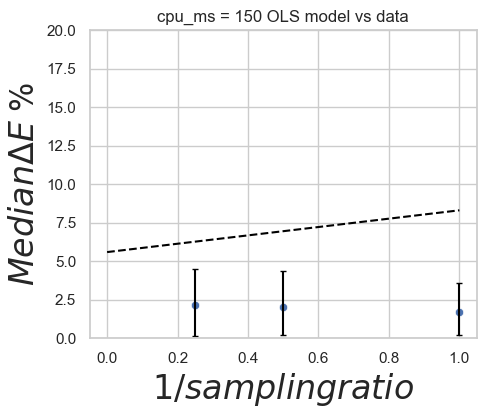

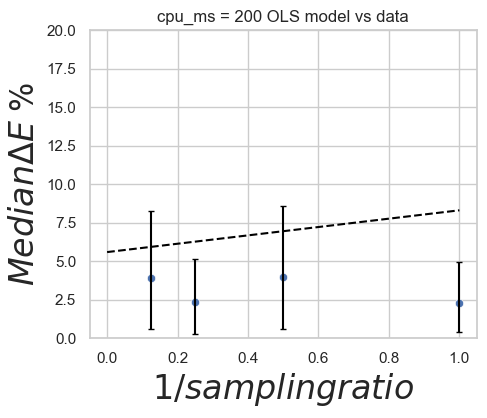

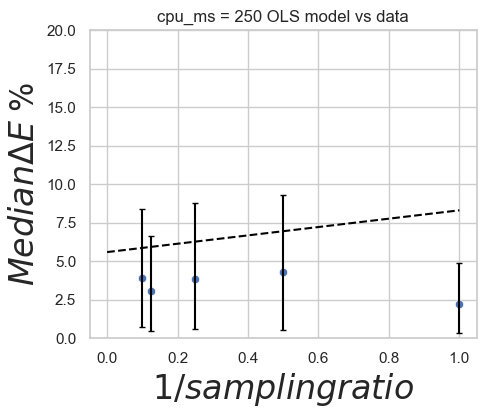

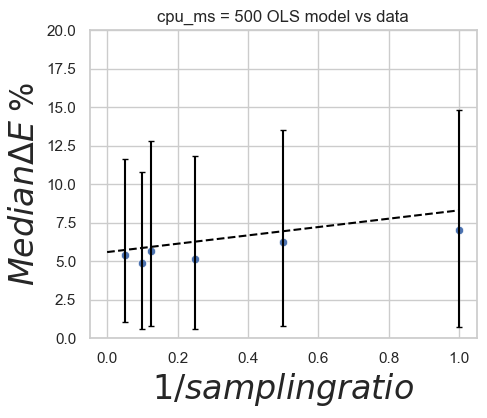

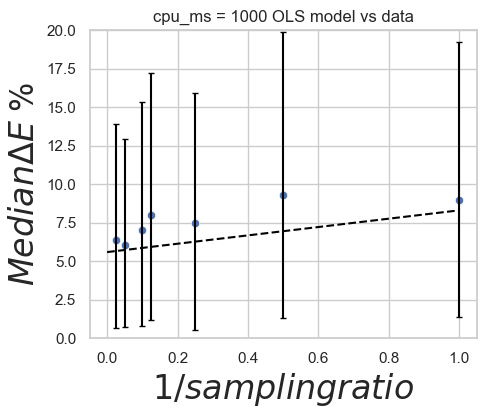

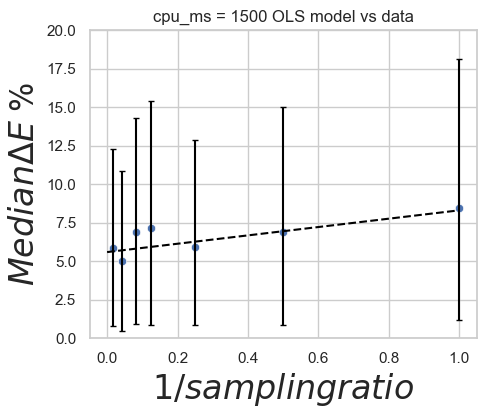

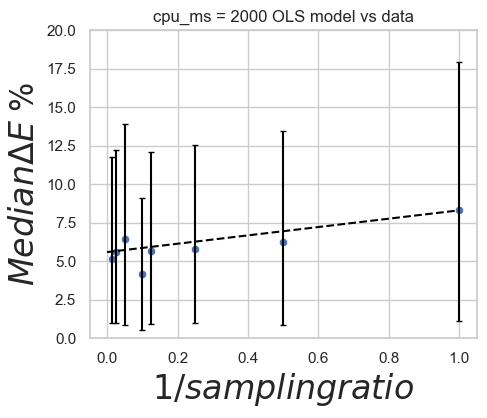

In [138]:
span_lengths = np.unique(df_median_dev.cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    tmp_df = df_median_dev.drop(['sampling_ratio','sqrt_recip_sampling_ratio'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(5,4))
    sns.scatterplot(data=tmp_df, x=tmp_df['recip_sampling_ratio'], y=tmp_df['median_energy_deviation'])
    plt.errorbar(tmp_df['recip_sampling_ratio'], tmp_df['median_energy_deviation'], yerr=[tmp_df['delta_e_lower_ci'],tmp_df['delta_e_upper_ci'] ], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, reg_model(x_vals), color="black", linestyle="--")
    plt.ylim(0,20)
    plt.xlabel(r"${1/samplingratio}$", fontsize=fs)
    plt.ylabel(r'$Median \Delta E$ %', fontsize=fs)
    plt.title("cpu_ms = "+str(i)+" OLS model vs data")
    plt.show()

## So, looks like accuracy of within 2.5 to 5% for under 500 ms, and between 5 to 7.5% for longer

In [139]:
df_spans_300

,trace_id,span_id,measurements_count,start_time_us,energy_joules,start_energy_joules,end_energy_joules,kepler_duration_ms,kepler_energy_joules,exper_name,cpu_ms,active_interval_ms,concurrency
0,1ea5821d6a8fa0ad3a4d62264de8ed5c,aaf34123177dd6a3,2,1775540696166682,7.377548,1178.432309,1179.653244,70,0,uniform-a,100,100,1.0
1,f03a4100613fa59a6f6e1dc8e2bb32c8,00f11b8c51d7729e,2,1775540677340915,7.311865,1039.834229,1040.469107,83,0,uniform-a,100,100,1.0
2,3e8e7c240b1f39549d89e55c2a2a32ce,20aa996537c2980a,2,1775540795264114,7.288992,110.473547,111.392257,100,0,uniform-a,100,100,1.0
3,866b5c2e6de51cf877ca48ed6b4e8caa,82b59d8a5efb3edd,2,1775540717968697,7.236388,1340.756535,1341.585087,99,0,uniform-a,100,100,1.0
4,872b66e51f39bd154ad1542fe80553fd,45b01753397306ba,2,1775540721937734,7.374696,1370.105189,1370.945295,97,0,uniform-a,100,100,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13487,84f0c207bc7cf850409bb7ba13caaf2b,063a4de1f4f6dd70,6,1775546325430563,5.359041,0.239662,5.594838,208,0,uniform-a,500,62,1.0
13488,728960a9d753b9a046900d9d74437b23,8cdf3e2fd703ba5c,6,1775546315512034,9.155061,10.834292,16.610591,188,0,uniform-a,500,62,1.0
13489,9e11773b40646f7debf5fc37e9282bc5,c066e79eba8a0ef5,6,1775546346252291,8.998294,35.821468,40.952971,234,0,uniform-a,500,62,1.0
13490,5543782e336402b00139b052ec0f0fa9,e30940845bda8a1f,5,1775546306590191,8.446099,63.661406,68.515457,249,0,uniform-a,500,62,1.0


## Instead try using Measurement Count since that is more useful for Firefly implementation

<Axes: xlabel='concurrency'>

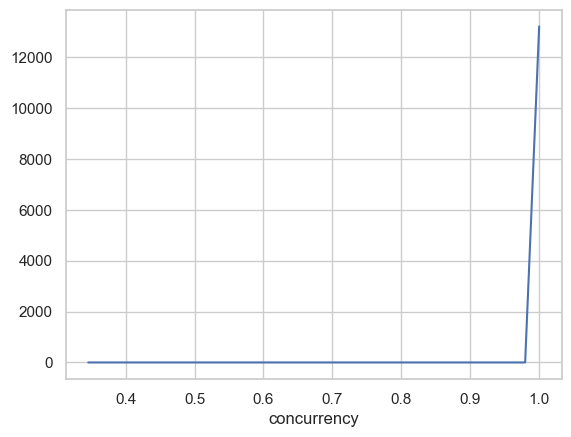

In [151]:
df_spans_300.groupby(['concurrency']).size().plot()

### Starting with only concurrency = 1 data

In [153]:
# create reduced dataset for modeling
df_msmt = df_spans_300.query('concurrency == 1.0').drop([ 'trace_id', 'start_time_us','start_energy_joules', 'end_energy_joules',
       'kepler_duration_ms', 'kepler_energy_joules', 'exper_name', 'active_interval_ms','concurrency'], axis=1)
df_msmt

,span_id,measurements_count,energy_joules,cpu_ms
0,aaf34123177dd6a3,2,7.377548,100
1,00f11b8c51d7729e,2,7.311865,100
2,20aa996537c2980a,2,7.288992,100
3,82b59d8a5efb3edd,2,7.236388,100
4,45b01753397306ba,2,7.374696,100
...,...,...,...,...
13487,063a4de1f4f6dd70,6,5.359041,500
13488,8cdf3e2fd703ba5c,6,9.155061,500
13489,c066e79eba8a0ef5,6,8.998294,500
13490,e30940845bda8a1f,5,8.446099,500


Text(37.453125000000014, 0.5, '$Energy [J]$')

<Figure size 1000x1000 with 0 Axes>

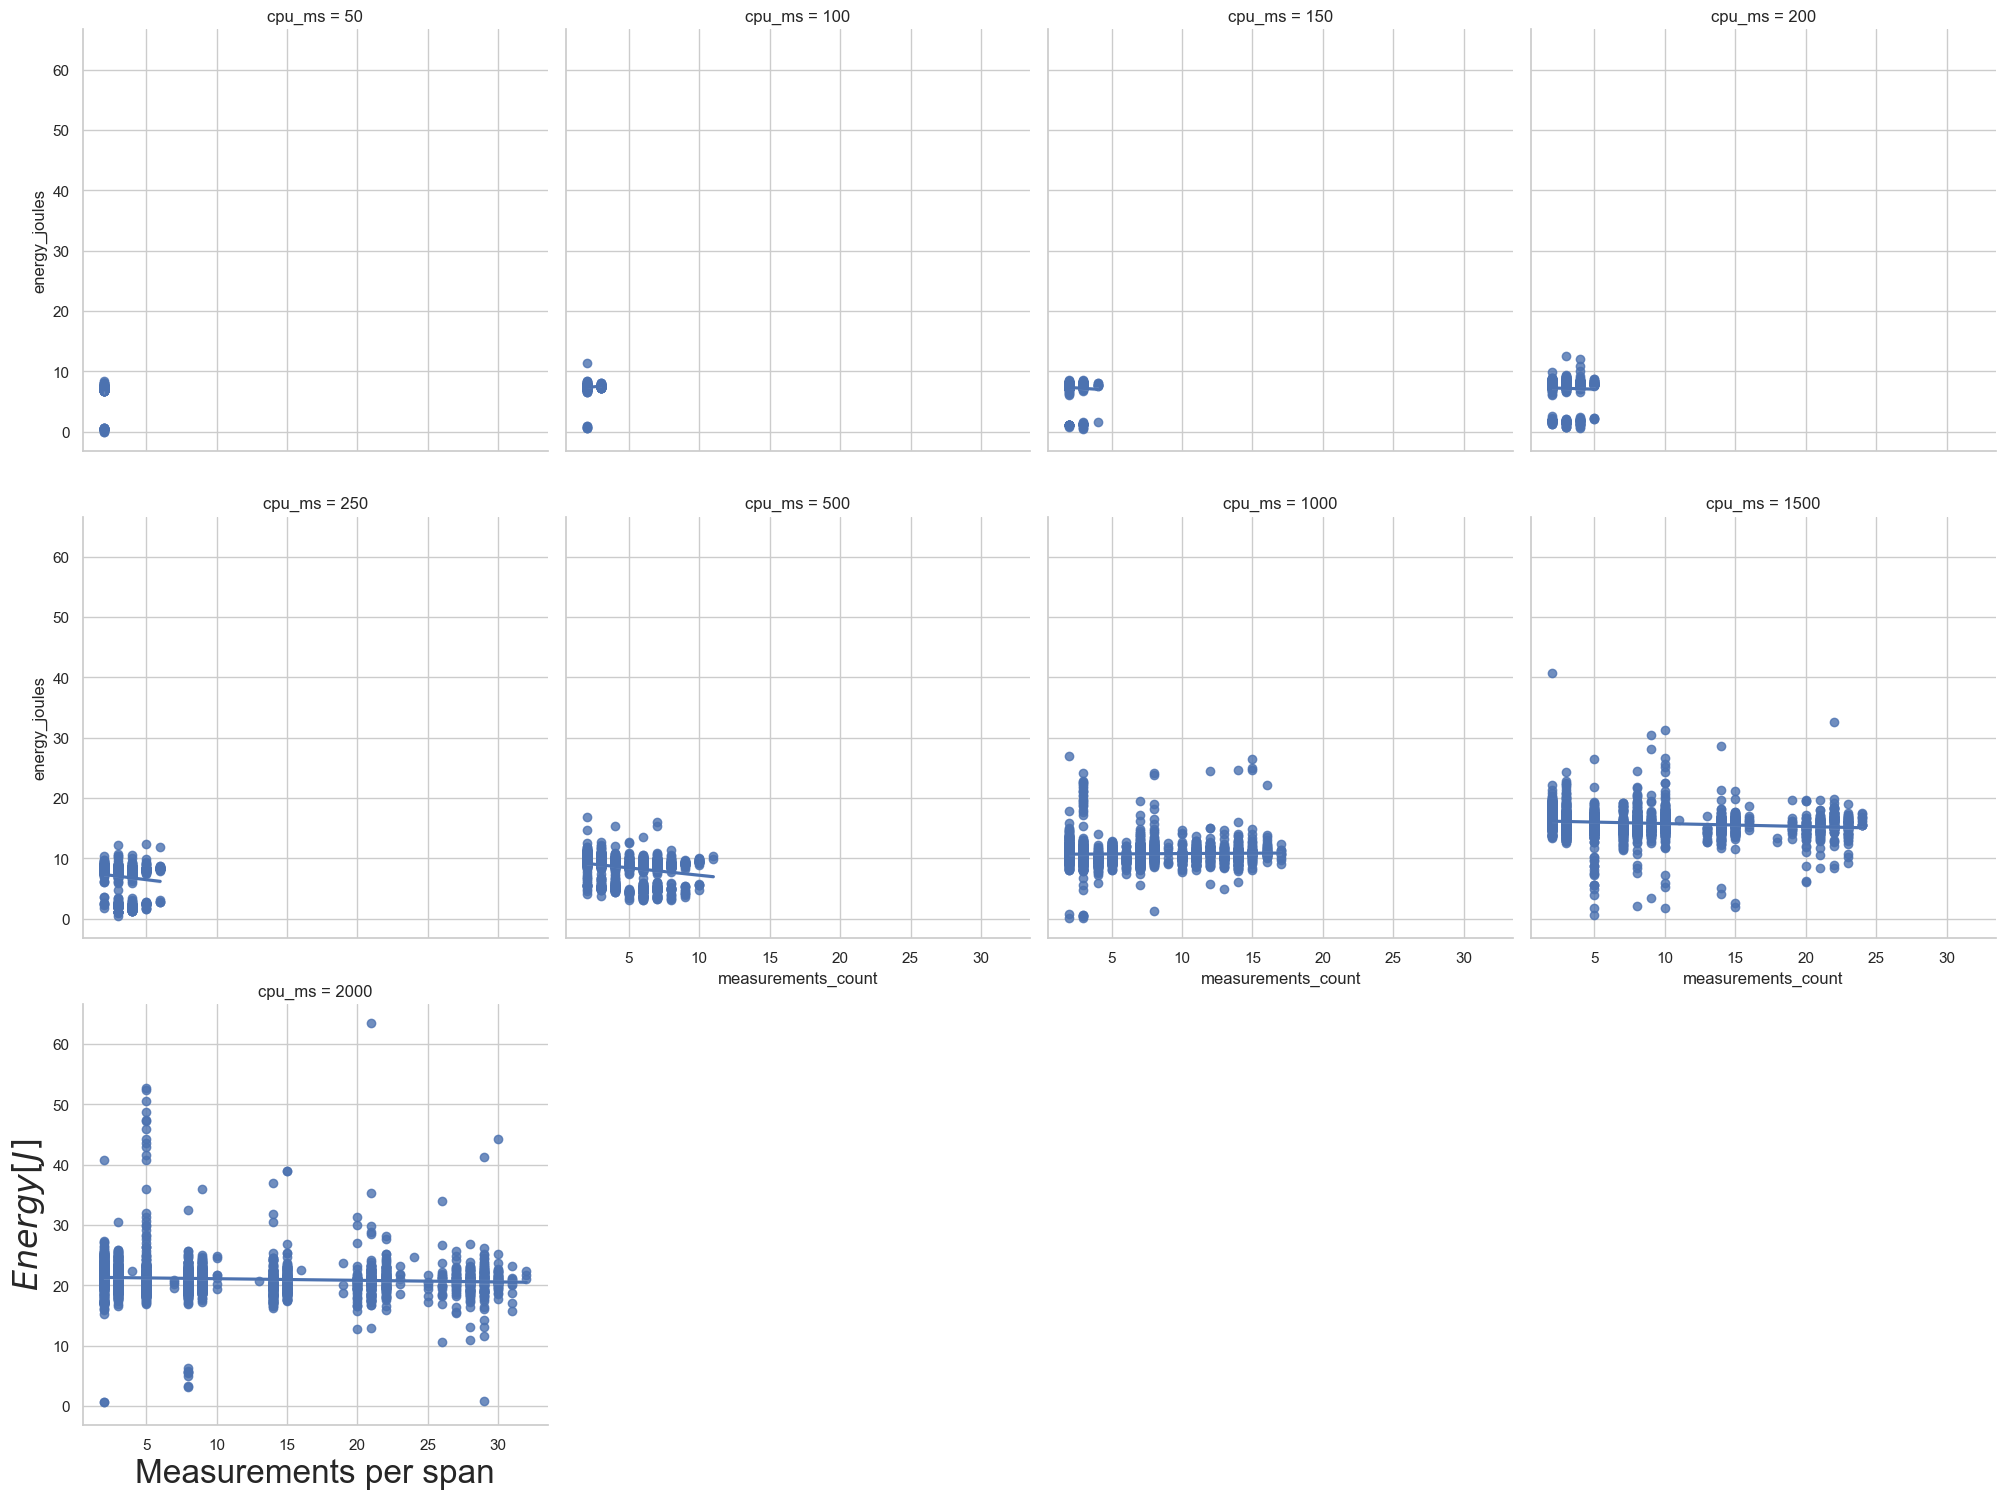

In [154]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_msmt, x='measurements_count', y='energy_joules', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel("Measurements per span", fontsize=fs)
plt.ylabel(r'$Energy [J]$', fontsize=fs)

/var/folders/ml/p381h5fs0x9g7g5ksj8fh6qh0000gn/T/ipykernel_31037/1939210486.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df_msmt, x='measurements_count', y='energy_joules', col='cpu_ms', col_wrap=4, palette='tab10', kind='box')


Text(16.694444444444443, 0.5, '$Energy [J]$')

<Figure size 1000x1000 with 0 Axes>

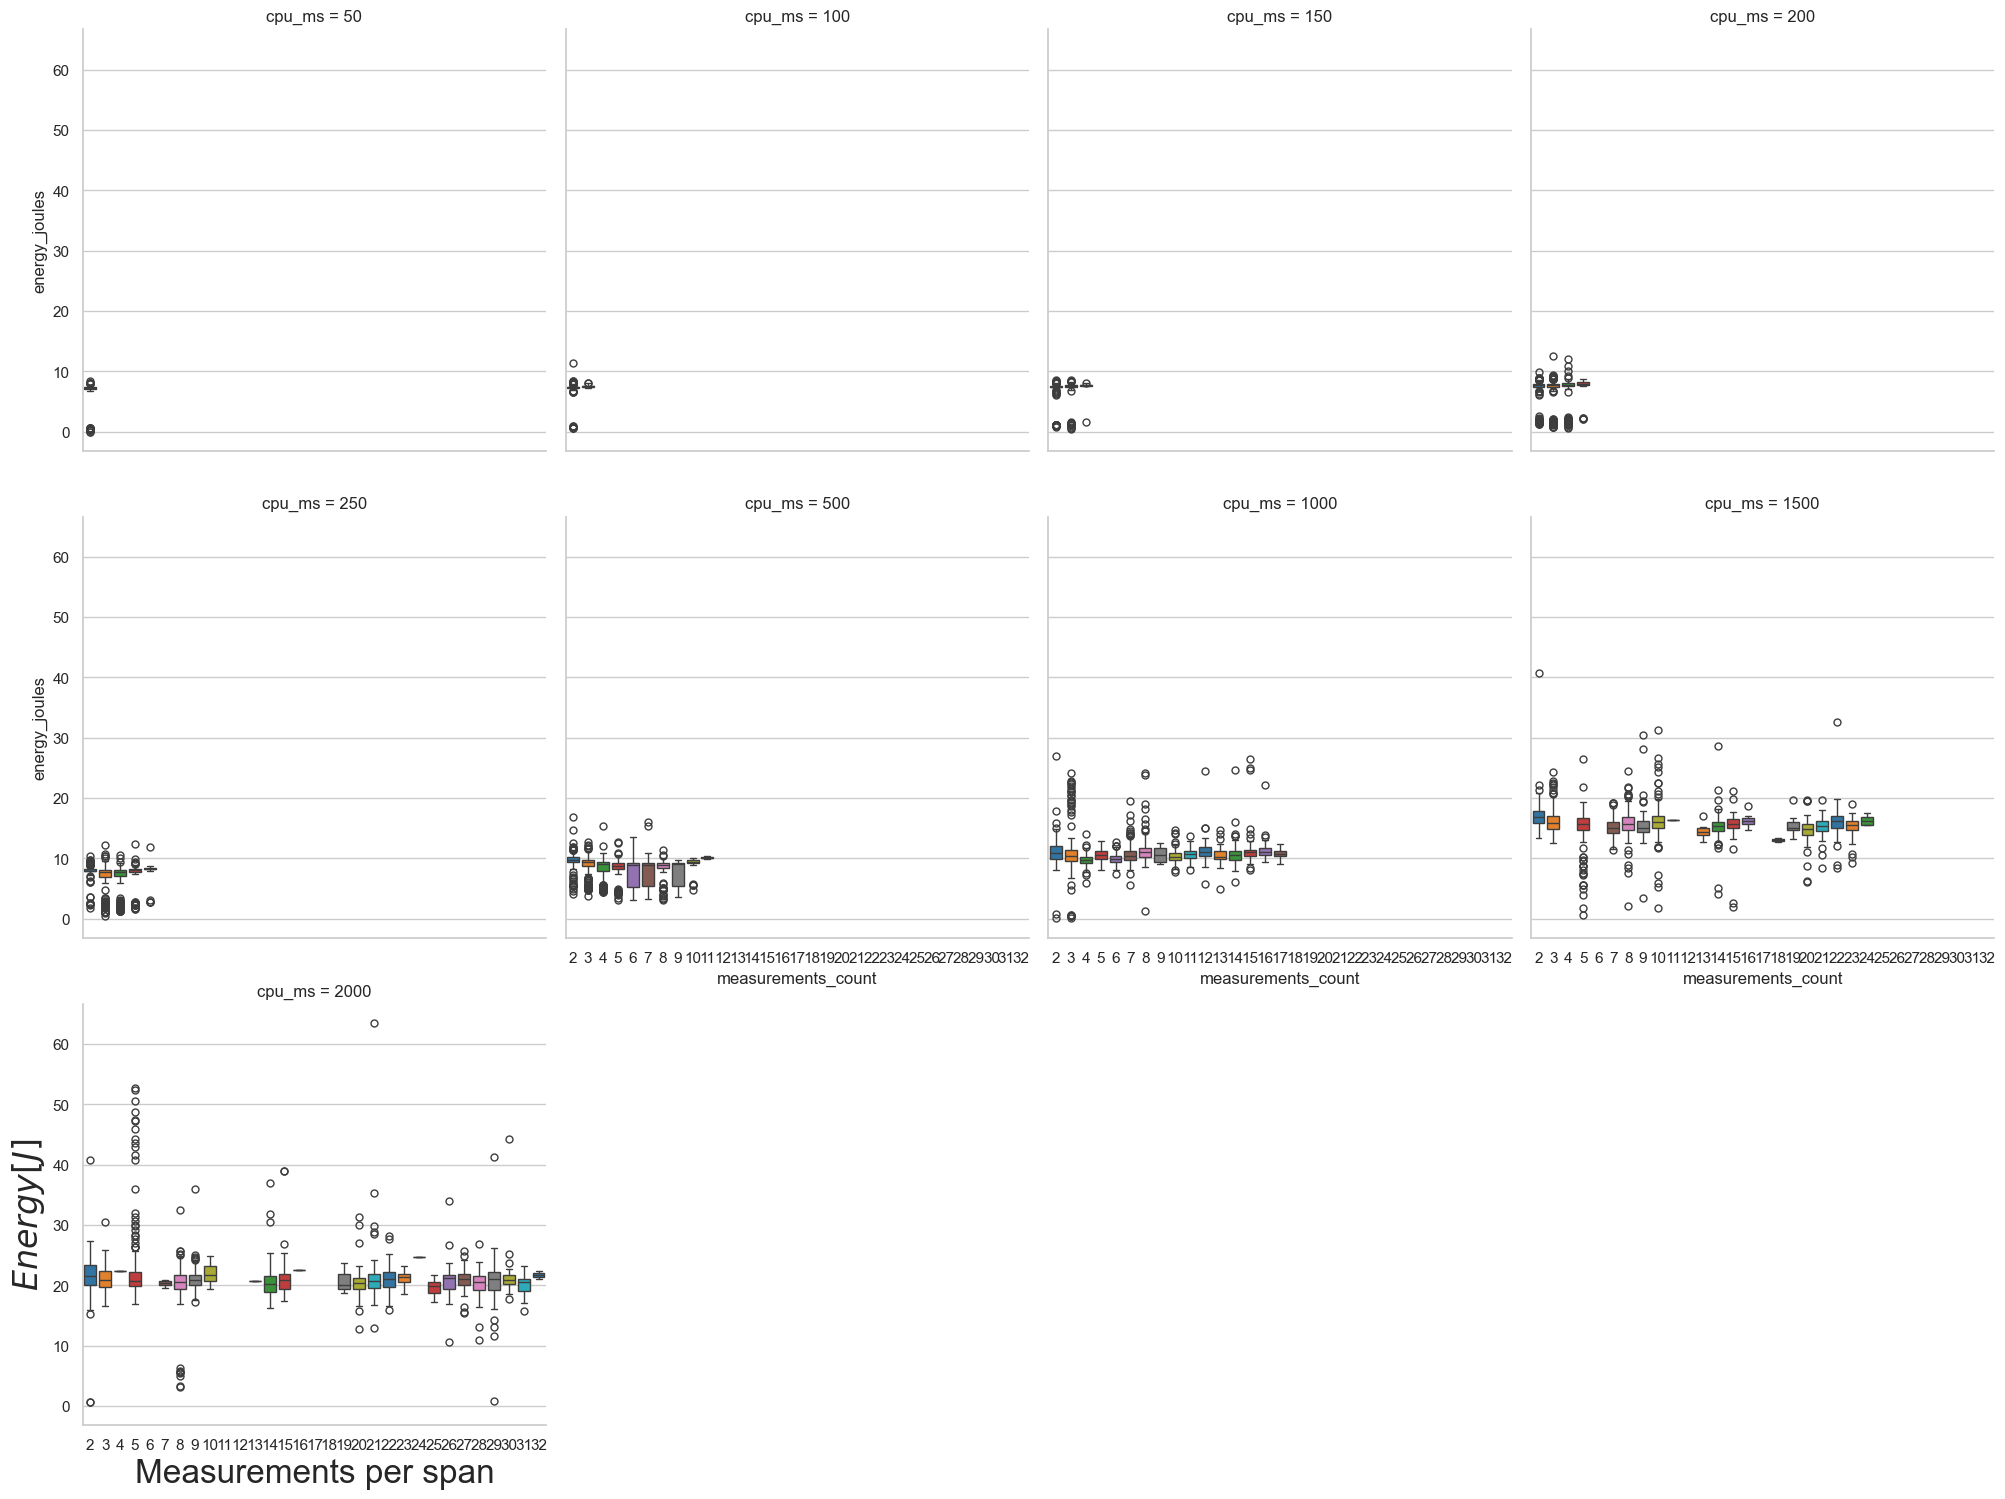

In [156]:
plt.figure(figsize=(10,10))
sns.catplot(data=df_msmt, x='measurements_count', y='energy_joules', col='cpu_ms', col_wrap=4, palette='tab10', kind='box')
plt.xlabel("Measurements per span", fontsize=fs)
plt.ylabel(r'$Energy [J]$', fontsize=fs)